### In this notebook the code for validation plot generation is given

#### Uniform tumor validation

In [8]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "validation" else Path.cwd()
CSV = ROOT / "outputs/validation/uniform_tumor_ode.csv"
FIGURE = ROOT / "outputs/paper/figures/uniform_tumor_convergence"


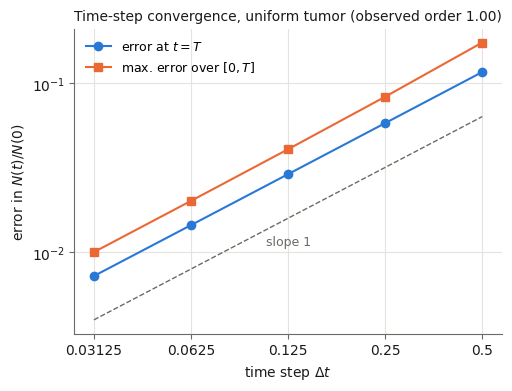

In [ ]:
SERIES = {
    "final_error": ("error at $t = T$", "#2a78d6", "o"),
    "max_error_over_time": ("max. error over $[0, T]$", "#eb6834", "s"),
}
INK, MUTED, GRID = "#1a1a19", "#6b6a64", "#e4e3dd"

data = pd.read_csv(CSV).sort_values("dt")
dt = data["dt"].to_numpy()

fig, ax = plt.subplots(figsize=(5.0, 3.8), layout="constrained")

for column, (label, colour, marker) in SERIES.items():
    ax.loglog(dt, data[column], color=colour, marker=marker, markersize=6,
              linewidth=1.5, label=label, zorder=3)

reference = data["final_error"].iloc[0] * dt / dt[0] * 0.55
ax.loglog(dt, reference, color=MUTED, linestyle="--", linewidth=1.0, zorder=2)
ax.annotate("slope 1", xy=(dt[2], reference[2]), xytext=(0, -12),
            textcoords="offset points", ha="center", va="top", color=MUTED, fontsize=9)

order = data["final_error_order"].dropna().iloc[0]
ax.set_xlabel(r"time step $\Delta t$", color=INK)
ax.set_ylabel("error in $N(t)/N(0)$", color=INK)
ax.set_xticks(dt, [f"{value:g}" for value in dt])
ax.minorticks_off()
ax.grid(True, which="major", color=GRID, linewidth=0.8)
ax.tick_params(colors=MUTED, labelcolor=INK)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(MUTED)
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.savefig(FIGURE.with_suffix(".pdf"))
fig.savefig(FIGURE.with_suffix(".png"), dpi=200)
plt.show()
